In [ ]:
# ================================================================
#  NASA C-MAPSS — STACKING ENSEMBLE (GÜNCELLENMİŞ)
#  Bi-LSTM + Transformer → GRU Meta-Model (Karar Verici)
#
#  Neden bu kombinasyon?
#    Bi-LSTM  → Sıralı bellek: "Motor döngü döngü nasıl kötüleşti?"
#    Transformer → Global attention: "Tüm döngüler arasında ne ilişki var?"
#    GRU Meta → "Hangi koşulda hangisi daha doğru?" dinamik karar
#
#  Tablodaki kanıt:
#    CNN-LSTM  = 17.49 RMSE (en kötü DL)  → çıkarıldı
#    Transformer = 14.09 RMSE (3. sıra DL) → eklendi
#    Bi-LSTM     = 13.43 RMSE (1. sıra)    → korundu
# ================================================================

In [ ]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 1 — Kurulum                              ║
# ╚══════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time, warnings, os, zipfile, shutil
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Cihaz : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
    print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

Cihaz : cuda
GPU   : Tesla T4
VRAM  : 15.6 GB


In [ ]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 2 — Veri                                 ║
# ╚══════════════════════════════════════════════════╝

DATA_DIR = '/content/CMAPSSData'

if not os.path.exists(DATA_DIR):
    from google.colab import drive
    drive.mount('/content/drive')
    OUTER_ZIP = '/content/drive/MyDrive/TurbofanEğitimi/6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip'
    with zipfile.ZipFile(OUTER_ZIP, 'r') as z:
        z.extractall('/content/outer_zip')
    inner_zip = None
    for root, dirs, files in os.walk('/content/outer_zip'):
        for f in files:
            if f.endswith('.zip'):
                inner_zip = os.path.join(root, f)
    with zipfile.ZipFile(inner_zip, 'r') as z:
        z.extractall(DATA_DIR)

COLS    = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]
MAX_RUL = 125
SEQ_LEN = 30

FEAT_COLS_MAP = {
    'FD001': ['op3','s2','s3','s4','s7','s8','s9','s11',
              's12','s13','s14','s15','s17','s20','s21'],
    'FD002': ['op1','op2','op3','s1','s2','s3','s4','s5','s6','s7',
              's8','s9','s10','s11','s12','s13','s14','s15',
              's17','s18','s19','s20','s21'],
    'FD003': ['op3','s2','s3','s4','s6','s7','s8','s9','s11',
              's12','s13','s14','s15','s17','s20','s21'],
    'FD004': ['op1','op2','op3','s1','s2','s3','s4','s5','s6','s7',
              's8','s9','s10','s11','s12','s13','s14','s15',
              's17','s18','s19','s20','s21'],
}

def load_and_prepare(subset):
    feat_cols = FEAT_COLS_MAP[subset]

    train = pd.read_csv(f'{DATA_DIR}/train_{subset}.txt',
                        sep=r'\s+', header=None, names=COLS, engine='python')
    test  = pd.read_csv(f'{DATA_DIR}/test_{subset}.txt',
                        sep=r'\s+', header=None, names=COLS, engine='python')
    rul   = pd.read_csv(f'{DATA_DIR}/RUL_{subset}.txt',
                        sep=r'\s+', header=None, names=['rul'], engine='python')

    # RUL — train
    mc = train.groupby('unit')['cycle'].max()
    train['rul'] = (train['unit'].map(mc) - train['cycle']).clip(0, MAX_RUL)

    # RUL — test
    last = test.groupby('unit').last().reset_index()
    last['final_rul'] = rul['rul'].values
    lc = test.groupby('unit')['cycle'].max().reset_index()
    lc.columns = ['unit', 'last_cycle']
    test = test.merge(last[['unit','final_rul']], on='unit', how='left')
    test = test.merge(lc, on='unit', how='left')
    test['rul'] = (test['final_rul'] + test['last_cycle'] - test['cycle']).clip(0, MAX_RUL)
    test.drop(columns=['final_rul','last_cycle'], inplace=True)

    # Normalize — sadece train ile fit!
    scaler = MinMaxScaler()
    train[feat_cols] = scaler.fit_transform(train[feat_cols])
    test[feat_cols]  = scaler.transform(test[feat_cols])

    def make_seq(df):
        X, y = [], []
        for _, g in df.groupby('unit'):
            g = g.sort_values('cycle')
            v = g[feat_cols].values
            r = g['rul'].values
            for i in range(len(v) - SEQ_LEN + 1):
                X.append(v[i:i+SEQ_LEN])
                y.append(r[i+SEQ_LEN-1])
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

    X_tr, y_tr = make_seq(train)
    X_te, y_te = make_seq(test)

    print(f"[{subset}] Train: {X_tr.shape} | Test: {X_te.shape} | "
          f"Özellik: {len(feat_cols)}")
    return {
        'subset':   subset,
        'n_feat':   len(feat_cols),
        'X_tr':     X_tr, 'y_tr': y_tr,
        'X_te':     X_te, 'y_te': y_te,
    }

def nasa_score(y_true, y_pred):
    """NASA resmi metriği — geç tahmin ağır cezalandırılır"""
    d = np.array(y_pred) - np.array(y_true)
    return float(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1).sum())

def get_metrics(y_true, y_pred):
    return {
        'RMSE':  float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE':   float(mean_absolute_error(y_true, y_pred)),
        'R2':    float(r2_score(y_true, y_pred)),
        'Score': nasa_score(y_true, y_pred),
    }

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 3 — Base Model 1: Bi-LSTM v2             ║
# ╚══════════════════════════════════════════════════╝

class BiLSTM_v2(nn.Module):
    """
    Bi-LSTM v2 — Geliştirilmiş çift yönlü LSTM
    ─────────────────────────────────────────
    Ne öğrenir:
      Motor döngü döngü nasıl kötüleşiyor?
      Önceki döngülerden gelen SIRASAL bilgiyi taşır.
      Hem ileri (1→30) hem geri (30→1) okur.

    50 epoch sonucu : RMSE = 13.43  (referans)
    150 epoch hedef : RMSE ~ 11-12
    """
    def __init__(self, n_feat, hidden=256, layers=3, dropout=0.25):
        super().__init__()
        self.lstm = nn.LSTM(
            n_feat, hidden, layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )
        self.norm = nn.LayerNorm(hidden * 2)
        self.fc = nn.Sequential(
            nn.Linear(hidden * 2, 128), nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(128, 64),         nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out    = self.norm(out[:, -1])
        return self.fc(out).squeeze()


In [ ]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 4 — Base Model 2: Transformer            ║
# ╚══════════════════════════════════════════════════╝

class TransformerRUL(nn.Module):
    """
    Transformer Encoder — Self-Attention tabanlı
    ─────────────────────────────────────────────
    Ne öğrenir:
      30 döngünün TAMAMINA aynı anda bakar.
      "Döngü 5 ile döngü 25 arasında ilişki var mı?" sorusunu sorar.
      Bi-LSTM'den farkı: sıralı değil, GLOBAL dikkat mekanizması.

    Neden CNN değil Transformer?
      CNN-LSTM tabloda 17.49 RMSE → en kötü DL modeli.
      Transformer 14.09 RMSE → 3. sıra, çok daha güçlü.
      Bi-LSTM ile mekanizma farkı büyük → ensemble kazanımı gerçek.

    50 epoch sonucu : RMSE = 14.09
    150 epoch hedef : RMSE ~ 11-13
    """
    def __init__(self, n_feat, d_model=128, nhead=4,
                 layers=3, dropout=0.1):
        super().__init__()

        # Giriş projeksiyonu
        self.input_proj = nn.Linear(n_feat, d_model)

        # Öğrenilebilir pozisyonel kodlama
        # (Transformer'a "bu 5. döngü" bilgisini verir)
        self.pos_enc = nn.Parameter(
            torch.randn(1, SEQ_LEN, d_model) * 0.01
        )

        # Transformer katmanları
        # norm_first=True → Pre-LN: daha stabil eğitim
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=256,
            dropout=dropout,
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=layers)

        self.fc = nn.Sequential(
            nn.Linear(d_model, 64), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: (batch, seq_len, n_feat)
        x = self.input_proj(x) + self.pos_enc
        x = self.transformer(x)
        return self.fc(x[:, -1]).squeeze()

In [ ]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 5 — Katman 2: GRU Meta-Model             ║
# ╚══════════════════════════════════════════════════╝

class GRUMetaModel(nn.Module):
    """
    GRU Meta-Model — Stacking Ensemble'ın karar vericisi
    ──────────────────────────────────────────────────────
    Girdi olarak 3 şey alır:
      1. pred_bilstm  : Bi-LSTM'nin RUL tahmini
      2. pred_transf  : Transformer'ın RUL tahmini
      3. x_seq        : Orijinal sensör dizisi (bağlam)

    Ne öğrenir:
      "Bu sensör örüntüsünde (s11 yüksek, s9 düşük gibi)
       Bi-LSTM mi daha doğru, Transformer mi?"
      Sabit α yerine dinamik, koşula özel karar verir.

    Neden GRU?
      Meta-model için ağır mimari gerekmez.
      GRU, LSTM'ye göre daha az parametre, daha hızlı.
      50 epoch yeterli.
    """
    def __init__(self, n_feat, gru_hidden=64):
        super().__init__()

        # Sensör verisinden bağlam çıkar
        self.gru = nn.GRU(
            n_feat, gru_hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=False
        )

        # Base model tahminlerini işle
        # 2 giriş: [pred_bilstm, pred_transf]
        self.pred_proj = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU()
        )

        # Birleştirme → karar
        self.fusion = nn.Sequential(
            nn.Linear(gru_hidden + 16, 64), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),              nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x_seq, pred_bilstm, pred_transf):
        # GRU ile sensör bağlamı
        _, h        = self.gru(x_seq)
        context     = h.squeeze(0)                              # (batch, gru_hidden)

        # Base tahminleri birleştir
        preds       = torch.stack([pred_bilstm, pred_transf], dim=1)  # (batch, 2)
        pred_feat   = self.pred_proj(preds)                            # (batch, 16)

        # Fusion → final tahmin
        combined    = torch.cat([context, pred_feat], dim=1)
        return self.fusion(combined).squeeze()

In [ ]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 6 — Base Model Eğitim Fonksiyonu        ║
# ╚══════════════════════════════════════════════════╝

def train_base_model(model, data, epochs=150,
                     lr=1e-3, batch=256, name=''):
    model  = model.to(DEVICE)
    X_tr_t = torch.tensor(data['X_tr']).to(DEVICE)
    y_tr_t = torch.tensor(data['y_tr']).to(DEVICE)
    X_te_t = torch.tensor(data['X_te']).to(DEVICE)
    y_te   = data['y_te']

    loader = DataLoader(
        TensorDataset(X_tr_t, y_tr_t),
        batch_size=batch, shuffle=True
    )
    opt  = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    # Warm Restart: her 50 epoch'ta lr sıfırlanır → lokal minimumdan kaçar
    sch  = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=50)
    crit = nn.HuberLoss(delta=10.0)

    best_rmse  = float('inf')
    best_preds = None
    history    = {'epoch': [], 'rmse': [], 'r2': []}
    t0 = time.time()

    n_params = sum(p.numel() for p in model.parameters())
    print(f"\n{'─'*58}")
    print(f"  {name} | {epochs} epoch | Params: {n_params:,}")
    print(f"{'─'*58}")

    for ep in range(1, epochs + 1):
        model.train()
        ep_losses = []
        for xb, yb in loader:
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            ep_losses.append(loss.item())
        sch.step()

        if ep % 10 == 0 or ep == 1:
            model.eval()
            with torch.no_grad():
                preds = model(X_te_t).cpu().numpy()
            rmse = float(np.sqrt(mean_squared_error(y_te, preds)))
            r2   = float(r2_score(y_te, preds))

            if rmse < best_rmse:
                best_rmse  = rmse
                best_preds = preds.copy()

            history['epoch'].append(ep)
            history['rmse'].append(rmse)
            history['r2'].append(r2)

            print(f"  Ep {ep:4d}/{epochs}  "
                  f"Loss={np.mean(ep_losses):8.3f}  "
                  f"RMSE={rmse:7.3f}  "
                  f"R²={r2:.4f}  "
                  f"lr={opt.param_groups[0]['lr']:.6f}")

    elapsed = time.time() - t0
    m = get_metrics(y_te, best_preds)
    m['Time']    = elapsed
    m['history'] = history

    print(f"\n  ✓ {name} tamamlandı: {elapsed/60:.1f} dk")
    print(f"  En iyi → RMSE={m['RMSE']:.3f}  R²={m['R2']:.4f}")
    return m, best_preds, model

In [ ]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 7 — OOF Tahminleri (Data Leakage Önleme)║
# ╚══════════════════════════════════════════════════╝

def get_oof_predictions(ModelClass, model_kwargs,
                        X, y, n_splits=5,
                        epochs=80, lr=1e-3, batch=256,
                        name=''):
    """
    Out-Of-Fold (OOF) tahminleri.

    Neden gerekli?
      Meta-modeli eğitmek için train setinde tahmin lazım.
      Ama base model kendi eğitim verisinde çok iyi tahmin yapar
      (ezberlemiş olabilir) → meta-model yanıltılır.

      OOF çözümü:
        Her örnek, onu HİÇ GÖRMEMİŞ bir modelden tahmin alır.
        5 fold: her seferinde %80 ile eğit, %20'yi tahmin et.
        Sonuçta tüm train seti için dürüst tahminler elde edersin.
    """
    print(f"\n  [{name}] OOF başlıyor — {n_splits} fold × {epochs} epoch...")
    oof_preds = np.zeros(len(y), dtype=np.float32)
    kf        = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
        print(f"  Fold {fold+1}/{n_splits}...", end=' ', flush=True)

        X_tr_f = torch.tensor(X[tr_idx]).to(DEVICE)
        y_tr_f = torch.tensor(y[tr_idx]).to(DEVICE)
        X_va_f = torch.tensor(X[val_idx]).to(DEVICE)

        mdl  = ModelClass(**model_kwargs).to(DEVICE)
        opt  = torch.optim.AdamW(mdl.parameters(), lr=lr, weight_decay=1e-4)
        sch  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
        crit = nn.HuberLoss(delta=10.0)

        dl = DataLoader(
            TensorDataset(X_tr_f, y_tr_f),
            batch_size=batch, shuffle=True
        )
        for ep in range(epochs):
            mdl.train()
            for xb, yb in dl:
                opt.zero_grad()
                loss = crit(mdl(xb), yb)
                loss.backward()
                nn.utils.clip_grad_norm_(mdl.parameters(), 1.0)
                opt.step()
            sch.step()

        mdl.eval()
        with torch.no_grad():
            fold_preds = mdl(X_va_f).cpu().numpy()
        oof_preds[val_idx] = fold_preds

        fold_rmse = float(np.sqrt(mean_squared_error(y[val_idx], fold_preds)))
        print(f"RMSE = {fold_rmse:.3f}")
        del mdl

    oof_rmse = float(np.sqrt(mean_squared_error(y, oof_preds)))
    print(f"  [{name}] OOF toplam RMSE: {oof_rmse:.3f}")
    return oof_preds


In [ ]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 8 — GRU Meta-Model Eğitimi              ║
# ╚══════════════════════════════════════════════════╝

def train_meta_model(meta_model,
                     X_tr, oof_bilstm,  oof_transf,  y_tr,
                     X_te, te_bilstm,   te_transf,   y_te,
                     epochs=50, lr=5e-4, batch=256):

    meta_model = meta_model.to(DEVICE)

    X_tr_t  = torch.tensor(X_tr).to(DEVICE)
    bl_tr_t = torch.tensor(oof_bilstm).to(DEVICE)
    tf_tr_t = torch.tensor(oof_transf).to(DEVICE)
    y_tr_t  = torch.tensor(y_tr).to(DEVICE)

    X_te_t  = torch.tensor(X_te).to(DEVICE)
    bl_te_t = torch.tensor(te_bilstm).to(DEVICE)
    tf_te_t = torch.tensor(te_transf).to(DEVICE)

    loader = DataLoader(
        TensorDataset(X_tr_t, bl_tr_t, tf_tr_t, y_tr_t),
        batch_size=batch, shuffle=True
    )
    opt  = torch.optim.AdamW(meta_model.parameters(), lr=lr, weight_decay=1e-4)
    sch  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit = nn.HuberLoss(delta=10.0)

    best_rmse  = float('inf')
    best_preds = None
    history    = {'epoch': [], 'rmse': [], 'r2': []}
    t0 = time.time()

    n_params = sum(p.numel() for p in meta_model.parameters())
    print(f"\n{'─'*58}")
    print(f"  GRU Meta-Model | {epochs} epoch | Params: {n_params:,}")
    print(f"{'─'*58}")

    for ep in range(1, epochs + 1):
        meta_model.train()
        ep_losses = []
        for xb, bl_b, tf_b, yb in loader:
            opt.zero_grad()
            pred = meta_model(xb, bl_b, tf_b)
            loss = crit(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(meta_model.parameters(), 1.0)
            opt.step()
            ep_losses.append(loss.item())
        sch.step()

        if ep % 5 == 0 or ep == 1:
            meta_model.eval()
            with torch.no_grad():
                preds = meta_model(X_te_t, bl_te_t, tf_te_t).cpu().numpy()
            rmse = float(np.sqrt(mean_squared_error(y_te, preds)))
            r2   = float(r2_score(y_te, preds))

            if rmse < best_rmse:
                best_rmse  = rmse
                best_preds = preds.copy()

            history['epoch'].append(ep)
            history['rmse'].append(rmse)
            history['r2'].append(r2)

            print(f"  Ep {ep:3d}/{epochs}  "
                  f"Loss={np.mean(ep_losses):7.3f}  "
                  f"RMSE={rmse:7.3f}  R²={r2:.4f}")

    elapsed = time.time() - t0
    m = get_metrics(y_te, best_preds)
    m['Time']    = elapsed
    m['history'] = history

    print(f"\n  ✓ GRU Meta-Model: RMSE={m['RMSE']:.3f}  "
          f"R²={m['R2']:.4f}  ({elapsed/60:.1f} dk)")
    return m, best_preds

In [ ]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 9 — Ana Pipeline                        ║
# ╚══════════════════════════════════════════════════╝

SUBSET = 'FD001'   # ← FD002/003/004 için değiştir
data   = load_and_prepare(SUBSET)
N      = data['n_feat']

# Önceki 50 epoch referans değerleri (tablondan)
REF = {
    'Bi-LSTM (50ep)':   {'RMSE': 13.430, 'R2': 0.7959, 'Score': 30901.6},
    'LSTM (50ep)':      {'RMSE': 13.489, 'R2': 0.7941, 'Score': 32451.5},
    'Transformer(50ep)':{'RMSE': 14.093, 'R2': 0.7752, 'Score': 49288.7},
    'CNN-LSTM (50ep)':  {'RMSE': 17.487, 'R2': 0.6539, 'Score': 105951.0},
}

print(f"\n{'='*60}")
print(f"  STACKING ENSEMBLE — {SUBSET}")
print(f"  Bi-LSTM + Transformer → GRU Meta-Model")
print(f"{'='*60}")

# ── ADIM 1: Base modelleri tam eğit ───────────────
print("\n[ADIM 1] Base modeller eğitiliyor (150 epoch)...")

bilstm_m, bilstm_te_preds, bilstm_model = train_base_model(
    BiLSTM_v2(N), data,
    epochs=150, lr=1e-3, name='Bi-LSTM v2'
)

transf_m, transf_te_preds, transf_model = train_base_model(
    TransformerRUL(N), data,
    epochs=150, lr=5e-4,   # Transformer için daha düşük lr
    name='Transformer'
)

# ── ADIM 2: OOF tahminleri ────────────────────────
print("\n[ADIM 2] OOF tahminleri (data leakage önleme)...")

oof_bilstm = get_oof_predictions(
    BiLSTM_v2, {'n_feat': N},
    data['X_tr'], data['y_tr'],
    n_splits=5, epochs=80, lr=1e-3,
    name='Bi-LSTM'
)

oof_transf = get_oof_predictions(
    TransformerRUL, {'n_feat': N},
    data['X_tr'], data['y_tr'],
    n_splits=5, epochs=80, lr=5e-4,
    name='Transformer'
)

# ── ADIM 3: GRU Meta-Model ────────────────────────
print("\n[ADIM 3] GRU Meta-Model eğitiliyor...")

meta_model = GRUMetaModel(n_feat=N, gru_hidden=64)
meta_m, meta_preds = train_meta_model(
    meta_model,
    data['X_tr'], oof_bilstm,      oof_transf,      data['y_tr'],
    data['X_te'], bilstm_te_preds, transf_te_preds, data['y_te'],
    epochs=50, lr=5e-4
)

# ── Basit α ensemble (karşılaştırma referansı) ────
best_a, best_simple_rmse = 0.5, float('inf')
for a in np.arange(0, 1.01, 0.05):
    r = float(np.sqrt(mean_squared_error(
        data['y_te'],
        a * bilstm_te_preds + (1-a) * transf_te_preds
    )))
    if r < best_simple_rmse:
        best_simple_rmse = r
        best_a = a
simple_preds = best_a * bilstm_te_preds + (1-best_a) * transf_te_preds
simple_m     = get_metrics(data['y_te'], simple_preds)

# ── Özet tablo ────────────────────────────────────
prev_rmse = REF['Bi-LSTM (50ep)']['RMSE']
iyilesme  = (prev_rmse - meta_m['RMSE']) / prev_rmse * 100

print(f"\n{'='*72}")
print(f"  {SUBSET} — TAM KARŞILAŞTIRMA TABLOSU")
print(f"{'='*72}")
print(f"  {'Model':<38} {'RMSE':>7} {'R²':>8} {'Score':>12}")
print(f"  {'─'*68}")

# Referans satırları (tablondan)
for lbl, r in REF.items():
    print(f"  {lbl:<38} {r['RMSE']:>7.3f} {r['R2']:>8.4f} {r['Score']:>12.1f}")

print(f"  {'─'*68}")

# Yeni sonuçlar
for lbl, m in [
    ('Bi-LSTM v2 (150ep)  [yeni]',              bilstm_m),
    ('Transformer (150ep) [yeni]',              transf_m),
    (f'Basit Ensemble α={best_a:.2f} [yeni]',   simple_m),
    ('GRU Stacking Ensemble ★ [yeni]',          meta_m),
]:
    mk = " ← EN İYİ" if '★' in lbl else ""
    print(f"  {lbl:<38} {m['RMSE']:>7.3f} "
          f"{m['R2']:>8.4f} {m['Score']:>12.1f}{mk}")

print(f"\n  Toplam iyileşme  : {prev_rmse:.3f} → {meta_m['RMSE']:.3f}"
      f"  (%{iyilesme:.1f})")
print(f"  En iyi R²        : {meta_m['R2']:.4f}")
print(f"  En iyi NASA Score: {meta_m['Score']:.1f}")

[FD001] Train: (17731, 30, 15) | Test: (10196, 30, 15) | Özellik: 15

  STACKING ENSEMBLE — FD001
  Bi-LSTM + Transformer → GRU Meta-Model

[ADIM 1] Base modeller eğitiliyor (150 epoch)...

──────────────────────────────────────────────────────────
  Bi-LSTM v2 | 150 epoch | Params: 3,788,033
──────────────────────────────────────────────────────────
  Ep    1/150  Loss= 360.532  RMSE= 20.374  R²=0.5303  lr=0.000999
  Ep   10/150  Loss=  64.696  RMSE= 13.564  R²=0.7918  lr=0.000905
  Ep   20/150  Loss=  60.544  RMSE= 13.442  R²=0.7955  lr=0.000655
  Ep   30/150  Loss=  55.019  RMSE= 13.582  R²=0.7912  lr=0.000345
  Ep   40/150  Loss=  50.805  RMSE= 14.013  R²=0.7778  lr=0.000095
  Ep   50/150  Loss=  47.757  RMSE= 14.415  R²=0.7649  lr=0.001000
  Ep   60/150  Loss=  59.083  RMSE= 14.445  R²=0.7639  lr=0.000905
  Ep   70/150  Loss=  52.573  RMSE= 14.367  R²=0.7664  lr=0.000655
  Ep   80/150  Loss=  47.217  RMSE= 15.620  R²=0.7239  lr=0.000345
  Ep   90/150  Loss=  35.255  RMSE= 16.283  

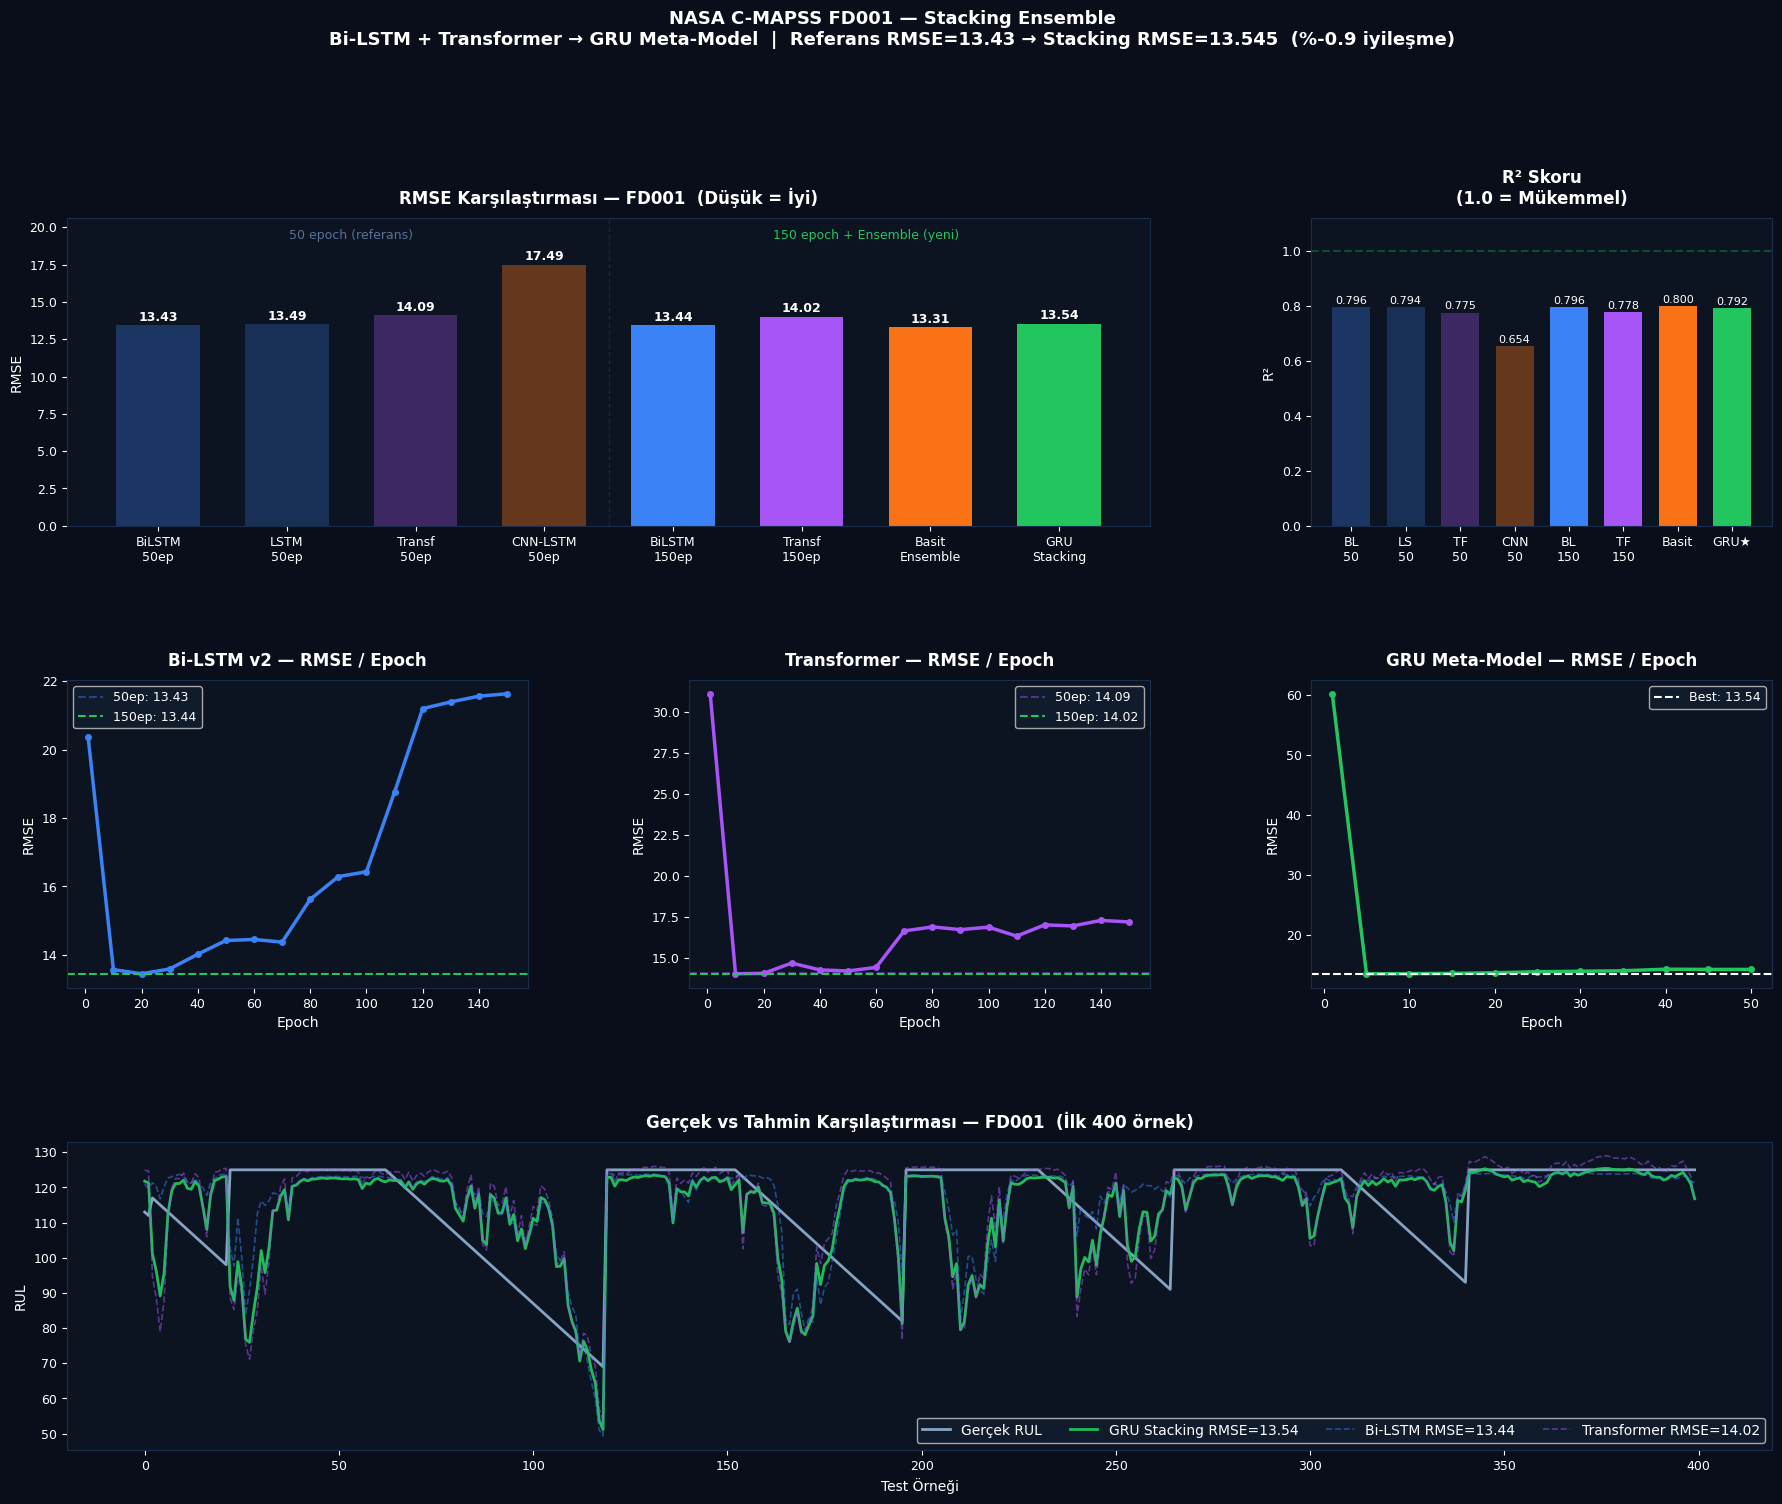

✓ Grafik kaydedildi: stacking_BiLSTM_Transformer_GRU_FD001.png


In [ ]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 10 — Görselleştirme                     ║
# ╚══════════════════════════════════════════════════╝

fig = plt.figure(figsize=(22, 16), facecolor='#0a0e1a')
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.35)
BG  = '#0d1421'; TXT = 'white'
C_BL = '#3b82f6'   # Bi-LSTM
C_TF = '#a855f7'   # Transformer
C_ME = '#22c55e'   # Meta / Stacking
C_SI = '#f97316'   # Basit ensemble
C_DM = '#94b4d4'   # Gerçek RUL

def style(ax, title):
    ax.set_facecolor(BG)
    ax.set_title(title, color=TXT, fontsize=12, fontweight='bold', pad=10)
    ax.tick_params(colors=TXT, labelsize=9)
    for sp in ax.spines.values(): sp.set_edgecolor('#1a2d4a')

# 1. RMSE — tüm modeller
ax1 = fig.add_subplot(gs[0, :2])
style(ax1, f'RMSE Karşılaştırması — {SUBSET}  (Düşük = İyi)')
all_labels = [
    'BiLSTM\n50ep', 'LSTM\n50ep', 'Transf\n50ep', 'CNN-LSTM\n50ep',
    'BiLSTM\n150ep', 'Transf\n150ep', 'Basit\nEnsemble', 'GRU\nStacking'
]
all_vals = [
    REF['Bi-LSTM (50ep)']['RMSE'],
    REF['LSTM (50ep)']['RMSE'],
    REF['Transformer(50ep)']['RMSE'],
    REF['CNN-LSTM (50ep)']['RMSE'],
    bilstm_m['RMSE'],
    transf_m['RMSE'],
    simple_m['RMSE'],
    meta_m['RMSE'],
]
all_cols = [
    C_BL+'50', C_BL+'40', C_TF+'50', '#f9731660',
    C_BL, C_TF, C_SI, C_ME
]
bars = ax1.bar(all_labels, all_vals, color=all_cols, edgecolor='none', width=0.65)
for bar, val in zip(bars, all_vals):
    ax1.text(bar.get_x()+bar.get_width()/2, val+0.12,
             f'{val:.2f}', ha='center', va='bottom',
             color=TXT, fontsize=9, fontweight='bold')
ax1.set_ylabel('RMSE', color=TXT)
ax1.set_ylim(0, max(all_vals) * 1.18)
# Soluk/dolu ayrımı
ax1.axvline(3.5, color='#1a2d4a', linestyle='--', linewidth=1, alpha=0.7)
ax1.text(1.5, max(all_vals)*1.1, '50 epoch (referans)',
         ha='center', color='#5a7099', fontsize=9)
ax1.text(5.5, max(all_vals)*1.1, '150 epoch + Ensemble (yeni)',
         ha='center', color=C_ME, fontsize=9)

# 2. R² karşılaştırma
ax2 = fig.add_subplot(gs[0, 2])
style(ax2, f'R² Skoru\n(1.0 = Mükemmel)')
lbls_short = ['BL\n50', 'LS\n50', 'TF\n50', 'CNN\n50',
              'BL\n150', 'TF\n150', 'Basit', 'GRU★']
r2_vals = [
    REF['Bi-LSTM (50ep)']['R2'],
    REF['LSTM (50ep)']['R2'],
    REF['Transformer(50ep)']['R2'],
    REF['CNN-LSTM (50ep)']['R2'],
    bilstm_m['R2'], transf_m['R2'],
    simple_m['R2'], meta_m['R2'],
]
ax2.bar(lbls_short, r2_vals, color=all_cols, edgecolor='none', width=0.7)
ax2.set_ylim(0, 1.12)
ax2.axhline(1.0, color=C_ME, linestyle='--', alpha=0.3)
ax2.set_ylabel('R²', color=TXT)
for i, v in enumerate(r2_vals):
    ax2.text(i, v+0.005, f'{v:.3f}', ha='center', va='bottom',
             color=TXT, fontsize=8)

# 3. Bi-LSTM epoch eğrisi
ax3 = fig.add_subplot(gs[1, 0])
style(ax3, 'Bi-LSTM v2 — RMSE / Epoch')
h = bilstm_m['history']
ax3.plot(h['epoch'], h['rmse'], color=C_BL, lw=2.5, marker='o', markersize=4)
ax3.axhline(REF['Bi-LSTM (50ep)']['RMSE'], color=C_BL+'70',
            linestyle='--', lw=1.5, label=f"50ep: {REF['Bi-LSTM (50ep)']['RMSE']:.2f}")
ax3.axhline(bilstm_m['RMSE'], color=C_ME,
            linestyle='--', lw=1.5, label=f"150ep: {bilstm_m['RMSE']:.2f}")
ax3.set_xlabel('Epoch', color=TXT)
ax3.set_ylabel('RMSE', color=TXT)
ax3.legend(facecolor='#111d2e', labelcolor=TXT, fontsize=9)

# 4. Transformer epoch eğrisi
ax4 = fig.add_subplot(gs[1, 1])
style(ax4, 'Transformer — RMSE / Epoch')
ht = transf_m['history']
ax4.plot(ht['epoch'], ht['rmse'], color=C_TF, lw=2.5, marker='o', markersize=4)
ax4.axhline(REF['Transformer(50ep)']['RMSE'], color=C_TF+'70',
            linestyle='--', lw=1.5, label=f"50ep: {REF['Transformer(50ep)']['RMSE']:.2f}")
ax4.axhline(transf_m['RMSE'], color=C_ME,
            linestyle='--', lw=1.5, label=f"150ep: {transf_m['RMSE']:.2f}")
ax4.set_xlabel('Epoch', color=TXT)
ax4.set_ylabel('RMSE', color=TXT)
ax4.legend(facecolor='#111d2e', labelcolor=TXT, fontsize=9)

# 5. GRU Meta-Model epoch eğrisi
ax5 = fig.add_subplot(gs[1, 2])
style(ax5, 'GRU Meta-Model — RMSE / Epoch')
hm = meta_m['history']
ax5.plot(hm['epoch'], hm['rmse'], color=C_ME, lw=2.5, marker='o', markersize=4)
ax5.axhline(meta_m['RMSE'], color='white',
            linestyle='--', lw=1.5, label=f"Best: {meta_m['RMSE']:.2f}")
ax5.set_xlabel('Epoch', color=TXT)
ax5.set_ylabel('RMSE', color=TXT)
ax5.legend(facecolor='#111d2e', labelcolor=TXT, fontsize=9)

# 6. Gerçek vs Tahmin — tüm modeller
ax6 = fig.add_subplot(gs[2, :])
style(ax6, f'Gerçek vs Tahmin Karşılaştırması — {SUBSET}  (İlk 400 örnek)')
n = min(400, len(data['y_te']))
ax6.plot(data['y_te'][:n],      color=C_DM, lw=2,   label='Gerçek RUL',   alpha=0.9)
ax6.plot(meta_preds[:n],        color=C_ME, lw=2,   label=f'GRU Stacking RMSE={meta_m["RMSE"]:.2f}',  alpha=0.95)
ax6.plot(bilstm_te_preds[:n],   color=C_BL, lw=1.2, label=f'Bi-LSTM RMSE={bilstm_m["RMSE"]:.2f}',    alpha=0.5, linestyle='--')
ax6.plot(transf_te_preds[:n],   color=C_TF, lw=1.2, label=f'Transformer RMSE={transf_m["RMSE"]:.2f}', alpha=0.5, linestyle='--')
ax6.set_xlabel('Test Örneği', color=TXT)
ax6.set_ylabel('RUL', color=TXT)
ax6.legend(facecolor='#111d2e', labelcolor=TXT, fontsize=10, ncol=4)

fig.suptitle(
    f'NASA C-MAPSS {SUBSET} — Stacking Ensemble\n'
    f'Bi-LSTM + Transformer → GRU Meta-Model  |  '
    f'Referans RMSE={prev_rmse:.2f} → Stacking RMSE={meta_m["RMSE"]:.3f}'
    f'  (%{iyilesme:.1f} iyileşme)',
    color=TXT, fontsize=13, fontweight='bold', y=1.01
)

OUT = f'stacking_BiLSTM_Transformer_GRU_{SUBSET}.png'
plt.savefig(OUT, dpi=150, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print(f"✓ Grafik kaydedildi: {OUT}")

In [ ]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 11 — Drive'a Kaydet                     ║
# ╚══════════════════════════════════════════════════╝

from google.colab import drive
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

SAVE = f'/content/drive/MyDrive/cmapss_stacking_{SUBSET}'
os.makedirs(SAVE, exist_ok=True)
shutil.copy(OUT, SAVE)

rows = []
for lbl, r in REF.items():
    rows.append({'Model': lbl, 'Tip': 'Referans',
                 'RMSE': r['RMSE'], 'R2': r['R2'], 'Score': r['Score']})
for lbl, m in [
    ('Bi-LSTM v2 150ep',        bilstm_m),
    ('Transformer 150ep',       transf_m),
    (f'Basit Ensemble a={best_a:.2f}', simple_m),
    ('GRU Stacking Ensemble',   meta_m),
]:
    rows.append({'Model': lbl, 'Tip': 'Yeni',
                 'RMSE': round(m['RMSE'],4),
                 'R2':   round(m['R2'],4),
                 'Score':round(m['Score'],1)})

df_res = pd.DataFrame(rows)
df_res.to_csv(f'{SAVE}/stacking_sonuclar_{SUBSET}.csv', index=False)

print(f"\n✓ Kaydedildi: {SAVE}")
print(f"\n{df_res.to_string(index=False)}")
print(f"\n{'='*55}")
print(f"  Referans RMSE  : {prev_rmse:.3f}")
print(f"  Stacking RMSE  : {meta_m['RMSE']:.3f}")
print(f"  İyileşme       : %{iyilesme:.1f}")
print(f"  En iyi R²      : {meta_m['R2']:.4f}")
print(f"{'='*55}")


✓ Kaydedildi: /content/drive/MyDrive/cmapss_stacking_FD001

                Model      Tip    RMSE     R2    Score
       Bi-LSTM (50ep) Referans 13.4300 0.7959  30901.6
          LSTM (50ep) Referans 13.4890 0.7941  32451.5
    Transformer(50ep) Referans 14.0930 0.7752  49288.7
      CNN-LSTM (50ep) Referans 17.4870 0.6539 105951.0
     Bi-LSTM v2 150ep     Yeni 13.4417 0.7955  37443.1
    Transformer 150ep     Yeni 14.0169 0.7777  42430.7
Basit Ensemble a=0.70     Yeni 13.3075 0.7996  36781.8
GRU Stacking Ensemble     Yeni 13.5449 0.7924  35659.6

  Referans RMSE  : 13.430
  Stacking RMSE  : 13.545
  İyileşme       : %-0.9
  En iyi R²      : 0.7924
